In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

COLOR_LIGHT = "#B0B7C3"
COLOR_MED   = "#5C7A99"
COLOR_DARK  = "#2E4057"
TEXT_COLOR  = "#1F2937"

plt.rcParams['font.size'] = 11
plt.rcParams['axes.edgecolor'] = TEXT_COLOR
plt.rcParams['text.color'] = TEXT_COLOR
plt.rcParams['axes.labelcolor'] = TEXT_COLOR
plt.rcParams['xtick.color'] = TEXT_COLOR
plt.rcParams['ytick.color'] = TEXT_COLOR

os.makedirs('../paper_figures', exist_ok=True)

In [2]:
train_df = pd.read_csv('../data/processed/train_cleaned.csv')
val_df = pd.read_csv('../data/processed/val_cleaned.csv')
test_df = pd.read_csv('../data/processed/test_cleaned.csv')

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Total reviews:", full_df.shape[0])
print(full_df['sentiment_label'].value_counts())

Total reviews: 4343
sentiment_label
positive    1985
neutral     1185
negative    1173
Name: count, dtype: int64


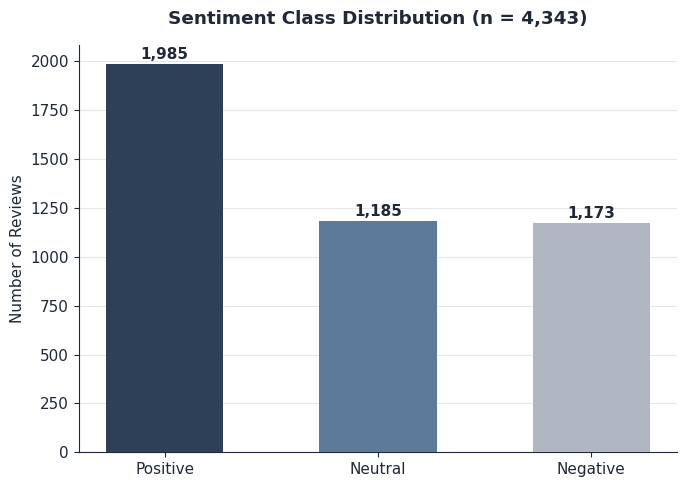

In [3]:
labels = full_df['sentiment_label'].value_counts().index.str.capitalize().tolist()
counts = full_df['sentiment_label'].value_counts().values.tolist()

order = ['Positive', 'Neutral', 'Negative']
counts = [counts[labels.index(l)] for l in order]
labels = order

colors = [COLOR_DARK, COLOR_MED, COLOR_LIGHT]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts, color=colors, width=0.55, zorder=3)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 25,
             f"{c:,}", ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel("Number of Reviews")
ax.set_title("Sentiment Class Distribution (n = 4,343)", fontweight='bold', pad=15)
ax.grid(axis='y', color='#E5E7EB', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../paper_figures/fig1_class_distribution.png", dpi=200, facecolor='white', bbox_inches='tight')
plt.show()

In [5]:
import joblib

X_test, y_test = joblib.load('../data/processed/test_features.pkl')

nb_model = joblib.load('../models/naive_bayes_model.pkl')
svm_model = joblib.load('../models/svm_model.pkl')
lr_model = joblib.load('../models/logistic_regression_model.pkl')

In [6]:
from sklearn.metrics import f1_score

# Classical models — computed live from your actual saved models
nb_pred = nb_model.predict(X_test)
svm_pred = svm_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

nb_f1 = f1_score(y_test, nb_pred, average='macro')
svm_f1 = f1_score(y_test, svm_pred, average='macro')
lr_f1 = f1_score(y_test, lr_pred, average='macro')

# Transformer models — loaded from the CSV you just downloaded
transformer_df = pd.read_csv('../results/transformer_results.csv', header=None, names=['model', 'macro_f1'])

print("Naive Bayes:", nb_f1)
print("SVM:", svm_f1)
print("Logistic Regression:", lr_f1)
print(transformer_df)

Naive Bayes: 0.5563531323299823
SVM: 0.6422385368274444
Logistic Regression: 0.6493859153229161
         model  macro_f1
0        MuRIL  0.677922
1  XLM-RoBERTa  0.692878


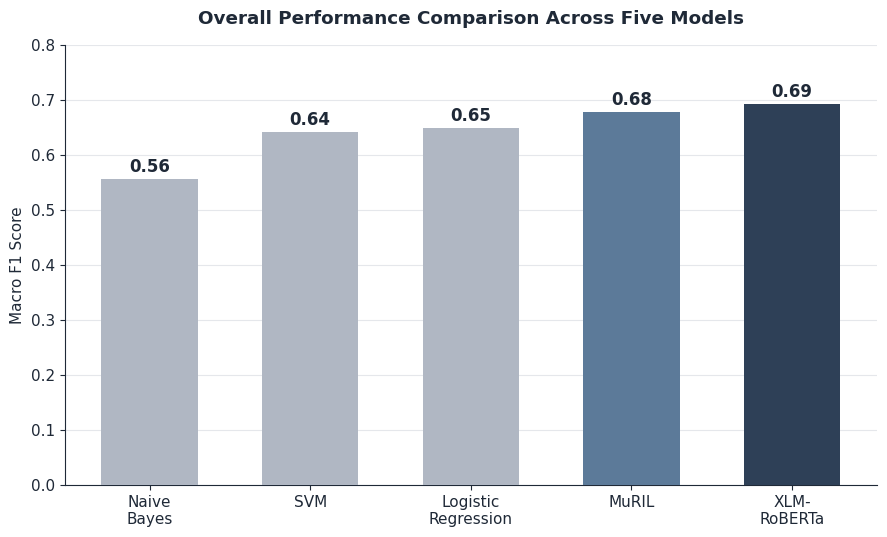

In [7]:
models = ["Naive\nBayes", "SVM", "Logistic\nRegression", "MuRIL", "XLM-\nRoBERTa"]
macro_f1 = [nb_f1, svm_f1, lr_f1, transformer_df.loc[0, 'macro_f1'], transformer_df.loc[1, 'macro_f1']]
colors = [COLOR_LIGHT]*3 + [COLOR_MED, COLOR_DARK]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(models, macro_f1, color=colors, width=0.6, zorder=3)
for bar, score in zip(bars, macro_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f"{score:.2f}", ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel("Macro F1 Score")
ax.set_ylim(0, 0.8)
ax.set_title("Overall Performance Comparison Across Five Models", fontweight='bold', pad=15)
ax.grid(axis='y', color='#E5E7EB', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../paper_figures/fig2_macro_f1_comparison.png", dpi=200, facecolor='white', bbox_inches='tight')
plt.show()

In [8]:
from sklearn.metrics import f1_score

classes_order = ['negative', 'neutral', 'positive']

nb_class_f1 = f1_score(y_test, nb_pred, average=None, labels=classes_order)
svm_class_f1 = f1_score(y_test, svm_pred, average=None, labels=classes_order)
lr_class_f1 = f1_score(y_test, lr_pred, average=None, labels=classes_order)

print("Naive Bayes:", nb_class_f1)
print("SVM:", svm_class_f1)
print("Logistic Regression:", lr_class_f1)

Naive Bayes: [0.59233449 0.344      0.7327249 ]
SVM: [0.65129683 0.50445104 0.77096774]
Logistic Regression: [0.68306011 0.49275362 0.77234401]


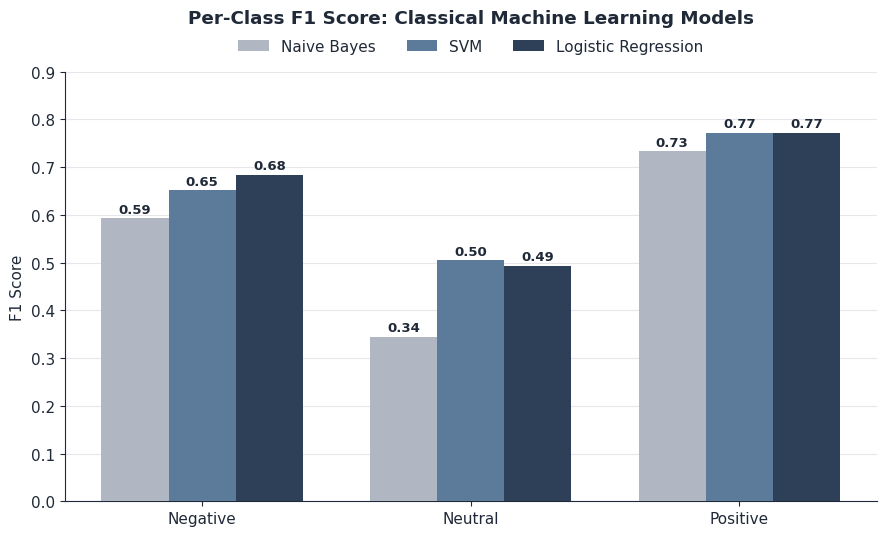

In [10]:
classes = ["Negative", "Neutral", "Positive"]
x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5.5))
bars_nb = ax.bar(x - width, nb_class_f1,  width, label='Naive Bayes', color=COLOR_LIGHT, zorder=3)
bars_svm = ax.bar(x,         svm_class_f1, width, label='SVM',          color=COLOR_MED, zorder=3)
bars_lr = ax.bar(x + width, lr_class_f1,  width, label='Logistic Regression', color=COLOR_DARK, zorder=3)

for bars in [bars_nb, bars_svm, bars_lr]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f"{bar.get_height():.2f}", ha='center', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 0.9)
ax.set_title("Per-Class F1 Score: Classical Machine Learning Models", fontweight='bold', pad=35)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=3, frameon=False)
ax.grid(axis='y', color='#E5E7EB', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../paper_figures/fig3_classical_per_class_f1.png", dpi=200, facecolor='white', bbox_inches='tight')
plt.show()

In [14]:
per_class_df = pd.read_csv('../results/transformer_per_class_f1.csv')
print(per_class_df)

         model  negative_f1  neutral_f1  positive_f1
0        MuRIL     0.682081    0.528736     0.822951
1  XLM-RoBERTa     0.722372    0.544910     0.811352


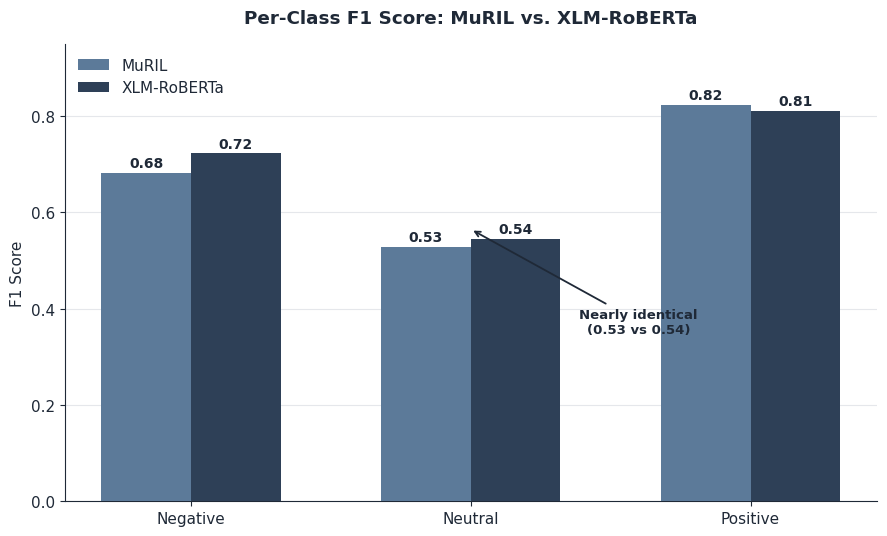

In [15]:
classes = ["Negative", "Neutral", "Positive"]
muril_vals = per_class_df.loc[per_class_df['model'] == 'MuRIL', ['negative_f1', 'neutral_f1', 'positive_f1']].values[0]
xlmr_vals = per_class_df.loc[per_class_df['model'] == 'XLM-RoBERTa', ['negative_f1', 'neutral_f1', 'positive_f1']].values[0]

x = np.arange(len(classes))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5.5))
b1 = ax.bar(x - width/2, muril_vals, width, label='MuRIL', color=COLOR_MED, zorder=3)
b2 = ax.bar(x + width/2, xlmr_vals,  width, label='XLM-RoBERTa', color=COLOR_DARK, zorder=3)

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                 f"{bar.get_height():.2f}", ha='center', fontsize=10, fontweight='bold')

# Highlight the neutral-class convergence
neutral_y = max(muril_vals[1], xlmr_vals[1]) + 0.02
ax.annotate(f'Nearly identical\n({muril_vals[1]:.2f} vs {xlmr_vals[1]:.2f})',
            xy=(1, neutral_y), xytext=(1.6, 0.35),
            fontsize=9.5, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=TEXT_COLOR, lw=1.3))

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 0.95)
ax.set_title("Per-Class F1 Score: MuRIL vs. XLM-RoBERTa", fontweight='bold', pad=15)
ax.legend(loc='upper left', frameon=False)
ax.grid(axis='y', color='#E5E7EB', zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("../paper_figures/fig4_muril_xlmr_per_class_f1.png", dpi=200, facecolor='white', bbox_inches='tight')
plt.show()

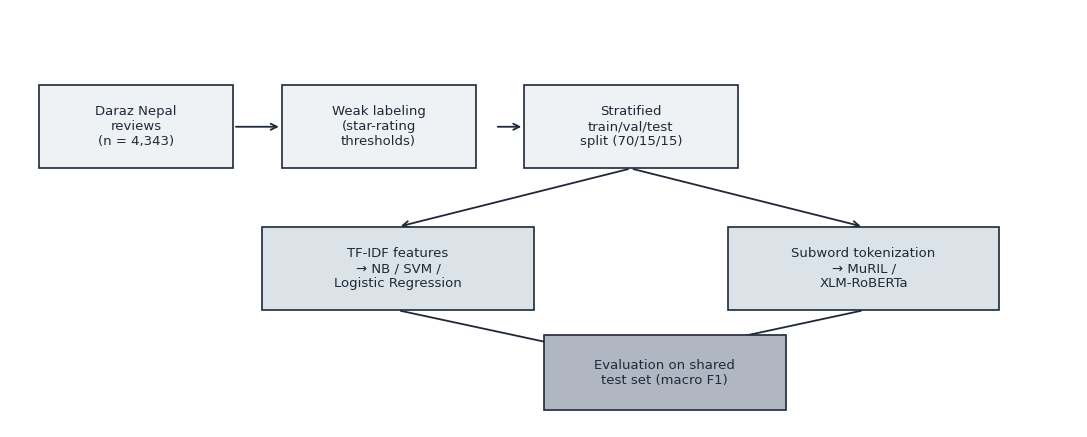

In [16]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.set_xlim(0, 11)
ax.set_ylim(-0.5, 4.5)
ax.axis('off')

def box(x, y, w, h, text, color="#EFF2F5"):
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor=TEXT_COLOR, lw=1.2, zorder=3)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=9.5, zorder=4)

def arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=TEXT_COLOR, lw=1.3), zorder=2)

box(0.3, 2.6, 2.0, 1.0, "Daraz Nepal\nreviews\n(n = 4,343)")
box(2.8, 2.6, 2.0, 1.0, "Weak labeling\n(star-rating\nthresholds)")
box(5.3, 2.6, 2.2, 1.0, "Stratified\ntrain/val/test\nsplit (70/15/15)")
arrow(2.3, 3.1, 2.8, 3.1)
arrow(5.0, 3.1, 5.3, 3.1)

arrow(6.4, 2.6, 4.0, 1.9)
arrow(6.4, 2.6, 8.8, 1.9)

box(2.6, 0.9, 2.8, 1.0, "TF-IDF features\n\u2192 NB / SVM /\nLogistic Regression", color="#DCE3E8")
box(7.4, 0.9, 2.8, 1.0, "Subword tokenization\n\u2192 MuRIL /\nXLM-RoBERTa", color="#DCE3E8")

arrow(4.0, 0.9, 6.0, 0.4)
arrow(8.8, 0.9, 6.8, 0.4)
box(5.5, -0.3, 2.5, 0.9, "Evaluation on shared\ntest set (macro F1)", color="#B0B7C3")

plt.tight_layout()
plt.savefig("../paper_figures/fig0_pipeline_diagram.png", dpi=200, facecolor='white', bbox_inches='tight')
plt.show()